In [ ]:
# =========================
# GOOGLE COLAB – FILE UPLOAD + DATASET LOAD
# =========================

from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Automatically get uploaded filename
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

# Basic verification
print("File loaded:", file_name)
print("Dataset shape:", df.shape)

# Preview data
df.head()


Saving FLAGGED_MIT-BIH Arrhythmia Database.csv to FLAGGED_MIT-BIH Arrhythmia Database.csv
File loaded: FLAGGED_MIT-BIH Arrhythmia Database.csv
Dataset shape: (100689, 36)


,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,conditions_met,flag
0,101,N,76,313,0.074347,-0.160548,1.036401,-0.285662,-0.026824,41,...,18,22,2,0.025930,0.025930,0.025930,0.025436,0.025436,3,0
1,101,N,313,315,-0.052079,-0.264784,0.886597,-0.366298,-0.059710,21,...,27,62,9,-0.042009,-0.029498,0.005012,0.030892,0.002986,2,0
2,101,N,315,321,-0.062151,-0.296983,0.991859,-0.410306,-0.065686,22,...,8,12,1,0.009528,0.009528,0.008786,0.008786,0.008368,2,0
3,101,N,321,336,-0.063322,-0.281386,1.034903,-0.403880,-0.071750,22,...,9,16,1,-0.020536,-0.020257,-0.018965,-0.016968,-0.014555,2,0
4,101,N,336,344,-0.062915,1.046914,1.046408,1.046408,-0.074639,11,...,5,31,10,0.016053,0.006742,0.002782,-0.007798,-0.051155,4,0


In [ ]:
# =========================================================
# SINGLE-BACKBONE HIERARCHICAL ARRHYTHMIA MODEL
# CNN-1D (Shallow Exit) → GRU
# FIXED: STAGE-1 CONFIDENCE + CLEAN FLOW
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    GlobalAveragePooling1D,
    GRU, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
CSV_PATH = "FLAGGED_MIT-BIH Arrhythmia Database.csv"
VALID_CLASSES = ["Q", "SVEB", "VEB", "F"]
SHALLOW_EXIT_AT = "pool2"   # pool1 | pool2
THRESHOLD = 0.35            # LOWERED threshold (important)

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv(CSV_PATH)
df["record"] = df["record"].astype(str)

TARGET_STAGE1 = "flag"
TARGET_STAGE2 = "type"

# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
exclude_cols = ["record", TARGET_STAGE1, TARGET_STAGE2]
feature_df = df.drop(columns=exclude_cols, errors="ignore")
feature_df = feature_df.apply(pd.to_numeric, errors="coerce")
feature_df = feature_df.fillna(feature_df.mean())

features_0 = [c for c in feature_df.columns if c.startswith("0_")]
features_1 = [c for c in feature_df.columns if c.startswith("1_")]

X0 = feature_df[features_0].values
X1 = feature_df[features_1].values

# shape → (samples, timesteps, channels)
X_seq = np.stack([X0, X1], axis=-1).astype(np.float32)

y_stage1 = df[TARGET_STAGE1].values.astype(np.float32)

# ---------------------------------------------------------
# STAGE-2 LABELS (ONLY ARRHYTHMIA)
# ---------------------------------------------------------
mask_stage2 = (y_stage1 == 1) & (df[TARGET_STAGE2].isin(VALID_CLASSES))

label_encoder = LabelEncoder()
y2_encoded = label_encoder.fit_transform(df.loc[mask_stage2, TARGET_STAGE2])
y2_cat = to_categorical(y2_encoded)

n_classes = y2_cat.shape[1]

y_stage2 = np.zeros((len(df), n_classes), dtype=np.float32)
y_stage2[mask_stage2.values] = y2_cat

# ---------------------------------------------------------
# SAMPLE WEIGHTS
# ---------------------------------------------------------
sw_stage1 = np.ones(len(df), dtype=np.float32)
sw_stage2 = mask_stage2.astype(np.float32).values

# ---------------------------------------------------------
# TRAIN / VAL SPLIT
# ---------------------------------------------------------
(
    X_train, X_val,
    y1_train, y1_val,
    y2_train, y2_val,
    sw1_train, sw1_val,
    sw2_train, sw2_val
) = train_test_split(
    X_seq,
    y_stage1,
    y_stage2,
    sw_stage1,
    sw_stage2,
    test_size=0.2,
    stratify=y_stage1,
    random_state=42
)

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
inputs = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# -------- SHARED CNN BACKBONE --------
x = Conv1D(32, 3, padding="same", activation="relu")(inputs)
x = MaxPooling1D(2)(x)

if SHALLOW_EXIT_AT == "pool1":
    shallow = x

x = Conv1D(64, 3, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)

if SHALLOW_EXIT_AT == "pool2":
    shallow = x

# -------- STAGE-1 (SHALLOW EXIT) --------
exit_feat = GlobalAveragePooling1D()(shallow)
exit_feat = Dense(32, activation="relu")(exit_feat)   # 🔧 FIX
stage1_out = Dense(1, activation="sigmoid", name="stage1")(exit_feat)

# -------- DEEP FEATURE EXTRACTOR --------
x = Conv1D(128, 3, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)

x = GRU(32)(x)
x = Dropout(0.3)(x)

stage2_out = Dense(n_classes, activation="softmax", name="stage2")(x)

model = Model(inputs, [stage1_out, stage2_out])

# ---------------------------------------------------------
# COMPILE
# ---------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=["binary_crossentropy", "categorical_crossentropy"],
    loss_weights=[2.0, 1.0],    # 🔧 FIX: strengthen Stage-1
    metrics=["accuracy", "accuracy"]
)

model.summary()

# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

model.fit(
    X_train,
    [y1_train, y2_train],
    sample_weight=[sw1_train, sw2_train],
    validation_data=(X_val, [y1_val, y2_val]),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------------
# HIERARCHICAL INFERENCE (FIXED)
# ---------------------------------------------------------
def hierarchical_predict(idx, threshold=THRESHOLD):
    seq = X_seq[idx:idx+1]
    p1, p2 = model.predict(seq, verbose=0)

    print("Stage-1 probability:", float(p1[0, 0]))  # DEBUG

    if p1[0, 0] < threshold:
        return {"Arrhythmia": 0, "Type": "N"}

    cls = np.argmax(p2, axis=1)[0]
    return {
        "Arrhythmia": 1,
        "Type": label_encoder.inverse_transform([cls])[0]
    }

# ---------------------------------------------------------
# TEST
# ---------------------------------------------------------
idx = df[mask_stage2].index[0]
print("\n===== SAMPLE PREDICTION =====")
print(hierarchical_predict(idx))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 16, 32)    │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 8, 32)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 8, 64)     │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 4, 64)     │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4, 128)    │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 2, 128)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │     15,552 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1 (Dense)      │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2 (Dense)      │ (None, 3)         │         99 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,900 (191.02 KB)

 Trainable params: 48,900 (191.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 1.4018 - stage1_accuracy: 0.8998 - stage1_loss: 0.6877 - stage2_accuracy: 0.0923 - stage2_loss: 0.0264 - val_loss: 0.4802 - val_stage1_accuracy: 0.9150 - val_stage1_loss: 0.2298 - val_stage2_accuracy: 0.0159 - val_stage2_loss: 0.0207
Epoch 2/50
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.4456 - stage1_accuracy: 0.9173 - stage1_loss: 0.2119 - stage2_accuracy: 0.0649 - stage2_loss: 0.0218 - val_loss: 0.3924 - val_stage1_accuracy: 0.9190 - val_stage1_loss: 0.1909 - val_stage2_accuracy: 0.1042 - val_stage2_loss: 0.0106
Epoch 3/50
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.4012 - stage1_accuracy: 0.9211 - stage1_loss: 0.1946 - stage2_accuracy: 0.0869 - stage2_loss: 0.0119 - val_loss: 0.4175 - val_stage1_accuracy: 0.9189 - val_stage1_loss: 0.2045 - val_stage2_accuracy: 0.0554 - val_stage2_loss: 0.0084
Epoch 4/50
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.3556 - stage1_accuracy: 0.9266 - stage1_

In [ ]:
# =========================================================
# SINGLE-BACKBONE HIERARCHICAL ARRHYTHMIA MODEL
# CNN-1D (Shallow Exit) → GRU
# FIXED: STAGE-1 CONFIDENCE + CLEAN FLOW
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    GlobalAveragePooling1D,
    GRU, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
CSV_PATH = "FLAGGED_MIT-BIH Arrhythmia Database.csv"
VALID_CLASSES = ["Q", "SVEB", "VEB", "F"]
SHALLOW_EXIT_AT = "pool2"   # pool1 | pool2
THRESHOLD = 0.35

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv(CSV_PATH)
df["record"] = df["record"].astype(str)

TARGET_STAGE1 = "flag"
TARGET_STAGE2 = "type"

# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
exclude_cols = ["record", TARGET_STAGE1, TARGET_STAGE2]
feature_df = df.drop(columns=exclude_cols, errors="ignore")
feature_df = feature_df.apply(pd.to_numeric, errors="coerce")
feature_df = feature_df.fillna(feature_df.mean())

features_0 = [c for c in feature_df.columns if c.startswith("0_")]
features_1 = [c for c in feature_df.columns if c.startswith("1_")]

X0 = feature_df[features_0].values
X1 = feature_df[features_1].values

# shape → (samples, timesteps, channels)
X_seq = np.stack([X0, X1], axis=-1).astype(np.float32)

y_stage1 = df[TARGET_STAGE1].values.astype(np.float32)

# ---------------------------------------------------------
# STAGE-2 LABELS (ONLY ARRHYTHMIA)
# ---------------------------------------------------------
mask_stage2 = (y_stage1 == 1) & (df[TARGET_STAGE2].isin(VALID_CLASSES))

label_encoder = LabelEncoder()
y2_encoded = label_encoder.fit_transform(df.loc[mask_stage2, TARGET_STAGE2])
y2_cat = to_categorical(y2_encoded)

n_classes = y2_cat.shape[1]

y_stage2 = np.zeros((len(df), n_classes), dtype=np.float32)
y_stage2[mask_stage2.values] = y2_cat

# ---------------------------------------------------------
# SAMPLE WEIGHTS
# ---------------------------------------------------------
sw_stage1 = np.ones(len(df), dtype=np.float32)
sw_stage2 = mask_stage2.astype(np.float32).values

# ---------------------------------------------------------
# TRAIN / VAL SPLIT
# ---------------------------------------------------------
(
    X_train, X_val,
    y1_train, y1_val,
    y2_train, y2_val,
    sw1_train, sw1_val,
    sw2_train, sw2_val
) = train_test_split(
    X_seq,
    y_stage1,
    y_stage2,
    sw_stage1,
    sw_stage2,
    test_size=0.2,
    stratify=y_stage1,
    random_state=42
)

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
inputs = Input(shape=(X_seq.shape[1], X_seq.shape[2]))

# -------- SHARED CNN BACKBONE --------
x = Conv1D(32, 3, padding="same", activation="relu")(inputs)
x = MaxPooling1D(2)(x)

if SHALLOW_EXIT_AT == "pool1":
    shallow = x

x = Conv1D(64, 3, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)

if SHALLOW_EXIT_AT == "pool2":
    shallow = x

# -------- STAGE-1 (SHALLOW EXIT) --------
exit_feat = GlobalAveragePooling1D()(shallow)
exit_feat = Dense(32, activation="relu")(exit_feat)
stage1_out = Dense(1, activation="sigmoid", name="stage1")(exit_feat)

# -------- DEEP FEATURE EXTRACTOR --------
x = Conv1D(128, 3, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)

x = GRU(32)(x)
x = Dropout(0.3)(x)

stage2_out = Dense(n_classes, activation="softmax", name="stage2")(x)

model = Model(inputs, [stage1_out, stage2_out])

# ---------------------------------------------------------
# COMPILE
# ---------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=["binary_crossentropy", "categorical_crossentropy"],
    loss_weights=[2.0, 1.0],
    metrics=["accuracy", "accuracy"]
)

model.summary()

# ---------------------------------------------------------
# TRAIN (UPDATED)
# ---------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train,
    [y1_train, y2_train],
    sample_weight=[sw1_train, sw2_train],
    validation_data=(X_val, [y1_val, y2_val]),
    epochs=100,          # ✅ UPDATED
    batch_size=256,      # ✅ UPDATED
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------------
# HIERARCHICAL INFERENCE
# ---------------------------------------------------------
def hierarchical_predict(idx, threshold=THRESHOLD):
    seq = X_seq[idx:idx+1]
    p1, p2 = model.predict(seq, verbose=0)

    print("Stage-1 probability:", float(p1[0, 0]))

    if p1[0, 0] < threshold:
        return {"Arrhythmia": 0, "Type": "N"}

    cls = np.argmax(p2, axis=1)[0]
    return {
        "Arrhythmia": 1,
        "Type": label_encoder.inverse_transform([cls])[0]
    }

# ---------------------------------------------------------
# TEST
# ---------------------------------------------------------
idx = df[mask_stage2].index[0]
print("\n===== SAMPLE PREDICTION =====")
print(hierarchical_predict(idx))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 16, 32)    │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 8, 32)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 8, 64)     │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 4, 64)     │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4, 128)    │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 2, 128)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │     15,552 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1 (Dense)      │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2 (Dense)      │ (None, 3)         │         99 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,900 (191.02 KB)

 Trainable params: 48,900 (191.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.5331 - stage1_accuracy: 0.9138 - stage1_loss: 0.2548 - stage2_accuracy: 0.1049 - stage2_loss: 0.0235 - val_loss: 0.4310 - val_stage1_accuracy: 0.9187 - val_stage1_loss: 0.2085 - val_stage2_accuracy: 0.0197 - val_stage2_loss: 0.0147
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.4288 - stage1_accuracy: 0.9180 - stage1_loss: 0.2066 - stage2_accuracy: 0.1102 - stage2_loss: 0.0156 - val_loss: 0.4025 - val_stage1_accuracy: 0.9189 - val_stage1_loss: 0.1977 - val_stage2_accuracy: 0.1107 - val_stage2_loss: 0.0080
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.3890 - stage1_accuracy: 0.9222 - stage1_loss: 0.1896 - stage2_accuracy: 0.0962 - stage2_loss: 0.0098 - val_loss: 0.3834 - val_stage1_accuracy: 0.9194 - val_stage1_loss: 0.1887 - val_stage2_accuracy: 0.0811 - val_stage2_loss: 0.0064
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.3672 - stage1_accuracy: 0.9279 - stage1_loss: 0

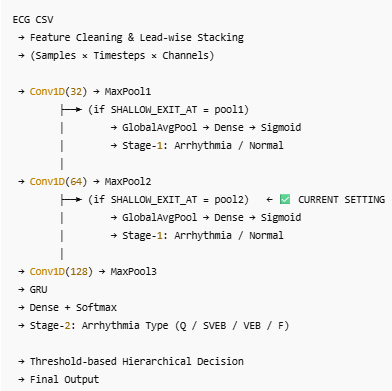


================ MODEL PERFORMANCE (STAGE-1) ================

CONFUSION MATRIX:
[[17949   475]
 [  326  1388]]

COUNTS:
TP = 1388, FP = 475, FN = 326, TN = 17949

CLASSIFICATION METRICS:
Accuracy           : 0.9602
Precision (PPV)    : 0.7450
Recall             : 0.8098
F1 Score           : 0.7761
Specificity        : 0.9742
NPV                : 0.9822
ROC AUC Score      : 0.9837

TRAINING METRICS:
Training Accuracy  : 0.9650
Validation Accuracy: 0.9590

ERROR METRICS:
MSE  : 0.0398
RMSE : 0.1994
MAE  : 0.0398
R²   : 0.4892


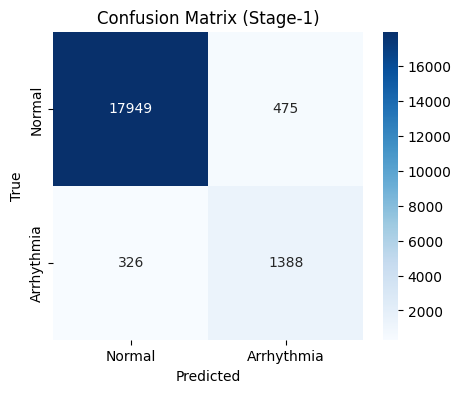

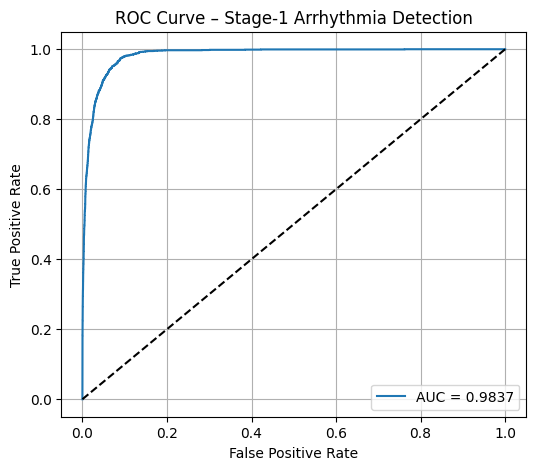

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 16, 32)    │        224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 8, 32)     │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 8, 64)     │      6,208 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 4, 64)     │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 4, 128)    │     24,704 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 2, 128)    │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │     15,552 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1 (Dense)      │ (None, 1)         │         33 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2 (Dense)      │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,702 (573.06 KB)

 Trainable params: 48,900 (191.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 97,802 (382.04 KB)

In [ ]:
# =========================================================
# COMPLETE EVALUATION BLOCK (ERROR-FREE)
# Stage-1: Arrhythmia Detection
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

# ---------------------------------------------------------
# GET PREDICTIONS
# ---------------------------------------------------------
p1_train, _ = model.predict(X_train, verbose=0)
p1_val,   _ = model.predict(X_val,   verbose=0)

y_train_pred = (p1_train >= THRESHOLD).astype(int).ravel()
y_val_pred   = (p1_val   >= THRESHOLD).astype(int).ravel()

y_train_true = y1_train.astype(int)
y_val_true   = y1_val.astype(int)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_val_true, y_val_pred)
TN, FP, FN, TP = cm.ravel()

# ---------------------------------------------------------
# CLASSIFICATION METRICS
# ---------------------------------------------------------
accuracy  = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)   # PPV
recall    = recall_score(y_val_true, y_val_pred)
f1        = f1_score(y_val_true, y_val_pred)

specificity = TN / (TN + FP)
npv         = TN / (TN + FN)

roc_auc = roc_auc_score(y_val_true, p1_val)

# ---------------------------------------------------------
# ERROR METRICS
# ---------------------------------------------------------
mse  = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val_true, y_val_pred)
r2   = r2_score(y_val_true, y_val_pred)

# ---------------------------------------------------------
# TRAIN / VAL ACCURACY (FROM HISTORY)
# ---------------------------------------------------------
train_acc = model.history.history["stage1_accuracy"][-1]
val_acc   = model.history.history["val_stage1_accuracy"][-1]

# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------
print("\n================ MODEL PERFORMANCE (STAGE-1) ================\n")

print("CONFUSION MATRIX:")
print(cm)

print("\nCOUNTS:")
print(f"TP = {TP}, FP = {FP}, FN = {FN}, TN = {TN}")

print("\nCLASSIFICATION METRICS:")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (PPV)    : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"NPV                : {npv:.4f}")
print(f"ROC AUC Score      : {roc_auc:.4f}")

print("\nTRAINING METRICS:")
print(f"Training Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

print("\nERROR METRICS:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# ---------------------------------------------------------
# CONFUSION MATRIX HEATMAP
# ---------------------------------------------------------
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Arrhythmia"],
            yticklabels=["Normal", "Arrhythmia"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Stage-1)")
plt.show()

# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------
fpr, tpr, _ = roc_curve(y_val_true, p1_val)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Stage-1 Arrhythmia Detection")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# MODEL ARCHITECTURE
# ---------------------------------------------------------
model.summary()



================ STAGE-2 PERFORMANCE =================

Classification Report:
              precision    recall  f1-score   support

           F       0.85      0.97      0.91        94
        SVEB       0.95      0.96      0.96        84
         VEB       0.99      0.95      0.97       319

    accuracy                           0.96       497
   macro avg       0.93      0.96      0.95       497
weighted avg       0.96      0.96      0.96       497

Overall Metrics:
Accuracy      : 0.9557
Precision     : 0.9323
Recall        : 0.9607
F1 Score      : 0.9451
ROC-AUC (OvR) : 0.9952

Error Metrics:
MSE  : 0.1348
RMSE : 0.3672
MAE  : 0.0744
R²   : 0.7847


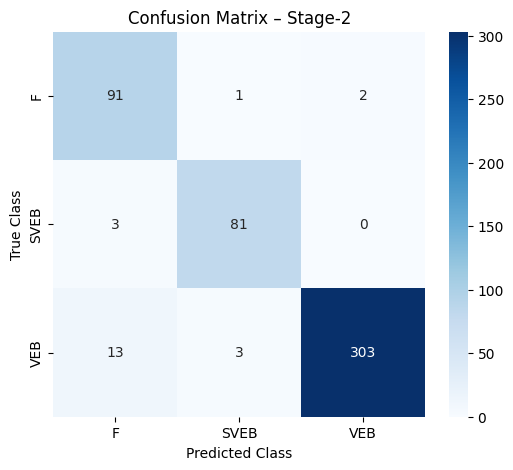

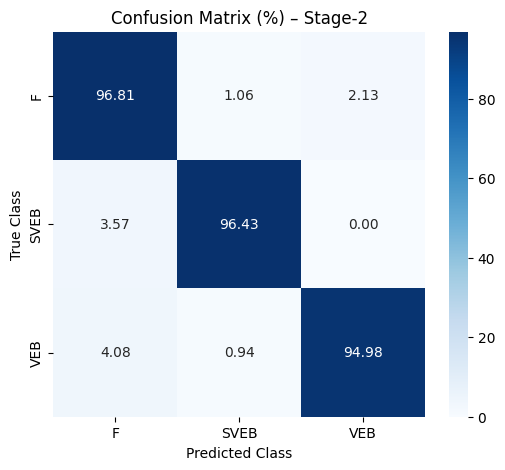

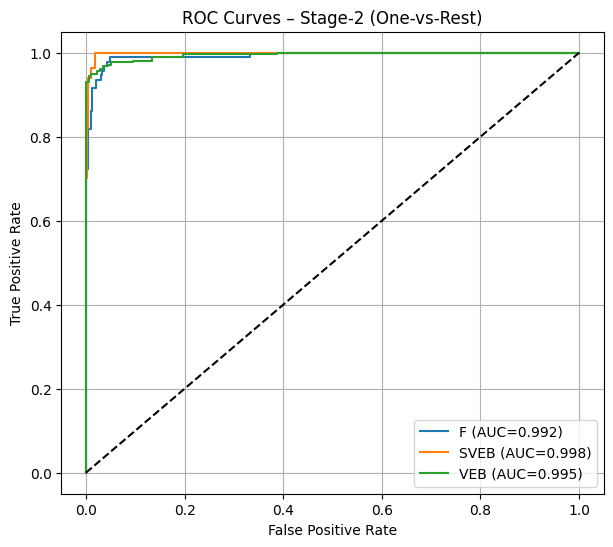

In [ ]:
# =========================================================
# COMPLETE EVALUATION BLOCK – STAGE-2 (ARRHYTHMIA TYPE)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# GET STAGE-2 PREDICTIONS (ONLY ARRHYTHMIA SAMPLES)
# ---------------------------------------------------------
_, p2_all = model.predict(X_val, verbose=0)

mask_stage2_eval = np.sum(y2_val, axis=1) > 0

y_true = np.argmax(y2_val[mask_stage2_eval], axis=1)
y_prob = p2_all[mask_stage2_eval]
y_pred = np.argmax(y_prob, axis=1)

class_names = label_encoder.classes_
n_classes = len(class_names)

# ---------------------------------------------------------
# BASIC METRICS
# ---------------------------------------------------------
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall    = recall_score(y_true, y_pred, average="macro")
f1        = f1_score(y_true, y_pred, average="macro")

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

# ---------------------------------------------------------
# ROC-AUC (ONE-vs-REST)
# ---------------------------------------------------------
y_true_bin = label_binarize(y_true, classes=range(n_classes))
roc_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")

# ---------------------------------------------------------
# ERROR METRICS (CLASS INDEX REGRESSION VIEW)
# ---------------------------------------------------------
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------
print("\n================ STAGE-2 PERFORMANCE =================\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Overall Metrics:")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC-AUC (OvR) : {roc_auc:.4f}")

print("\nError Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# ---------------------------------------------------------
# CONFUSION MATRIX (COUNTS)
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix – Stage-2")
plt.show()

# ---------------------------------------------------------
# CONFUSION MATRIX (PERCENTAGE)
# ---------------------------------------------------------
cm_percent = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (%) – Stage-2")
plt.show()

# ---------------------------------------------------------
# ROC CURVES (PER CLASS)
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Stage-2 (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()



================ END-TO-END MODEL PERFORMANCE ================

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98     18424
           F       0.74      0.24      0.36      1311
        SVEB       0.08      0.85      0.14        84
         VEB       0.50      0.78      0.61       319

    accuracy                           0.92     20138
   macro avg       0.57      0.71      0.52     20138
weighted avg       0.95      0.92      0.93     20138

Overall Metrics:
Accuracy      : 0.9228
Precision     : 0.5750
Recall        : 0.7095
F1 Score      : 0.5229
ROC-AUC       : 0.9723

Error Metrics:
MSE  : 0.2080
RMSE : 0.4560
MAE  : 0.1147
R²   : 0.0084


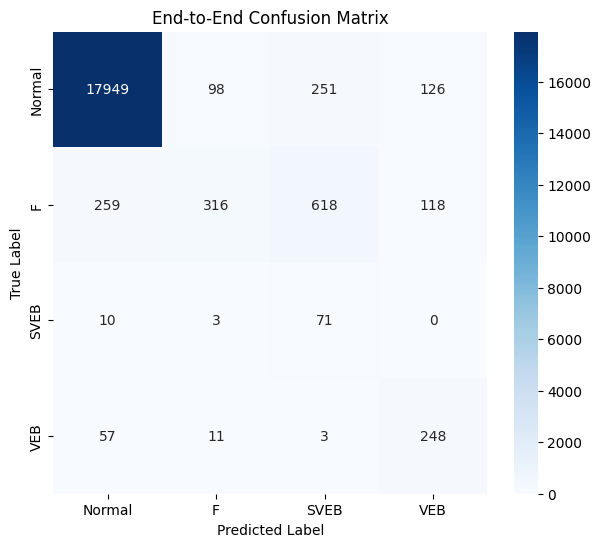

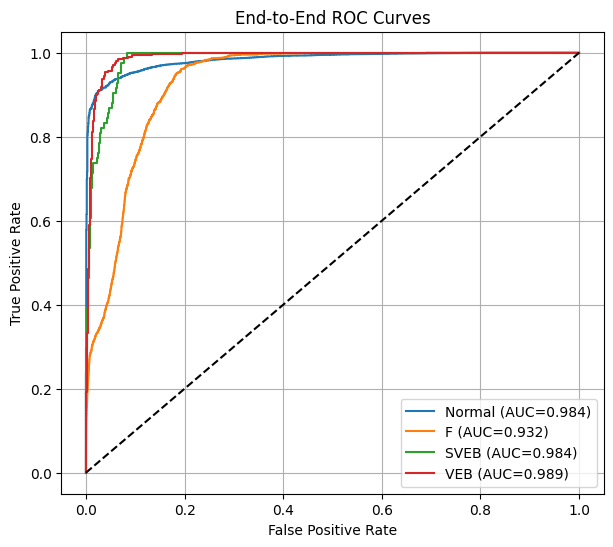

In [ ]:
# =========================================================
# END-TO-END(n vs other type analysis) HIERARCHICAL MODEL EVALUATION
# (STAGE-1 + STAGE-2 TOGETHER)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------
# GET MODEL PREDICTIONS
# ---------------------------------------------------------
p1_all, p2_all = model.predict(X_val, verbose=0)

# ---------------------------------------------------------
# TRUE LABELS
# ---------------------------------------------------------
y1_true = y1_val.astype(int)                     # Stage-1 truth
y2_true_full = np.argmax(y2_val, axis=1)         # Stage-2 truth (0 if not arrhythmia)

# ---------------------------------------------------------
# FINAL HIERARCHICAL PREDICTION
# ---------------------------------------------------------
FINAL_NORMAL = -1     # represent Normal class

y_final_true = []
y_final_pred = []

for i in range(len(X_val)):

    # ----- TRUE LABEL -----
    if y1_true[i] == 0:
        y_final_true.append(FINAL_NORMAL)
    else:
        y_final_true.append(y2_true_full[i])

    # ----- PREDICTED LABEL -----
    if p1_all[i, 0] < THRESHOLD:
        y_final_pred.append(FINAL_NORMAL)
    else:
        cls = np.argmax(p2_all[i])
        y_final_pred.append(cls)

y_final_true = np.array(y_final_true)
y_final_pred = np.array(y_final_pred)

# ---------------------------------------------------------
# CLASS NAMES (NORMAL + ARRHYTHMIA TYPES)
# ---------------------------------------------------------
class_names = ["Normal"] + list(label_encoder.classes_)
n_classes = len(class_names)

# Map labels → 0..N
y_final_true_mapped = y_final_true.copy()
y_final_pred_mapped = y_final_pred.copy()

y_final_true_mapped[y_final_true == FINAL_NORMAL] = 0
y_final_pred_mapped[y_final_pred == FINAL_NORMAL] = 0

y_final_true_mapped[y_final_true != FINAL_NORMAL] += 1
y_final_pred_mapped[y_final_pred != FINAL_NORMAL] += 1

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
accuracy  = accuracy_score(y_final_true_mapped, y_final_pred_mapped)
precision = precision_score(y_final_true_mapped, y_final_pred_mapped,
                            average="macro", zero_division=0)
recall    = recall_score(y_final_true_mapped, y_final_pred_mapped,
                         average="macro")
f1        = f1_score(y_final_true_mapped, y_final_pred_mapped,
                     average="macro")

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_final_true_mapped, y_final_pred_mapped)

# ---------------------------------------------------------
# ROC-AUC (MULTI-CLASS OvR)
# ---------------------------------------------------------
y_true_bin = label_binarize(
    y_final_true_mapped,
    classes=range(n_classes)
)

# build probability matrix
probs_full = np.zeros((len(X_val), n_classes))
probs_full[:, 0] = 1 - p1_all[:, 0]     # Normal
probs_full[:, 1:] = p2_all * p1_all     # gated by stage-1

roc_auc = roc_auc_score(
    y_true_bin,
    probs_full,
    average="macro",
    multi_class="ovr"
)

# ---------------------------------------------------------
# ERROR METRICS
# ---------------------------------------------------------
mse  = mean_squared_error(y_final_true_mapped, y_final_pred_mapped)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_final_true_mapped, y_final_pred_mapped)
r2   = r2_score(y_final_true_mapped, y_final_pred_mapped)

# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------
print("\n================ END-TO-END MODEL PERFORMANCE ================\n")

print("Classification Report:")
print(classification_report(
    y_final_true_mapped,
    y_final_pred_mapped,
    target_names=class_names
))

print("Overall Metrics:")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")

print("\nError Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# ---------------------------------------------------------
# CONFUSION MATRIX PLOT
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("End-to-End Confusion Matrix")
plt.show()

# ---------------------------------------------------------
# ROC CURVES (PER CLASS)
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_full[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("End-to-End ROC Curves")
plt.legend()
plt.grid(True)
plt.show()
